# **Dataset - AB_NYC_2019.csv**

# **Install Libraries and Upload Dataset**

In [ ]:
# Install required libraries
!pip install -q statsmodels mlxtend

In [ ]:
# Upload CSV file
from google.colab import files
uploaded = files.upload()

Saving AB_NYC_2019.csv to AB_NYC_2019.csv


In [ ]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot settings for Colab
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

# **Data Cleaning and Preprocessing**

In [ ]:
df = pd.read_csv('AB_NYC_2019.csv')

print('Shape:', df.shape)
df.head()

Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
# Data types
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [ ]:
# Missing values
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# Drop columns not useful for analysis
df.drop(columns=['id', 'host_name', 'last_review'], inplace=True)

# Fill missing values
df['reviews_per_month'].fillna(0, inplace=True)
df['name'].fillna('Unknown', inplace=True)

# Remove listings with price = 0 (invalid)
df = df[df['price'] > 0]

# Remove price outliers using IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['price'] >= Q1 - 1.5 * IQR) & (df['price'] <= Q3 + 1.5 * IQR)]

# Remove unrealistic minimum_nights
df = df[df['minimum_nights'] <= 365]

print('✅ Cleaned shape:', df.shape)
print('Missing values after cleaning:')
print(df.isnull().sum())

✅ Cleaned shape: (45899, 13)
Missing values after cleaning:
name                              0
host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


# **Exploratory Data Analysis**

In [ ]:
# Descriptive Statistics
num_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365']
df[num_cols].describe().round(2)

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,45899.00,45899.00,45899.00,45899.00,45899.00,45899.00
mean,120.00,6.76,23.95,1.11,6.64,109.33
std,68.14,16.00,45.32,1.61,31.02,130.25
min,10.00,1.00,0.00,0.00,1.00,0.00
25%,65.00,1.00,1.00,0.05,1.00,0.00
50%,100.00,2.00,5.00,0.38,1.00,39.00
75%,159.00,5.00,24.00,1.62,2.00,216.00
max,334.00,365.00,629.00,58.50,327.00,365.00


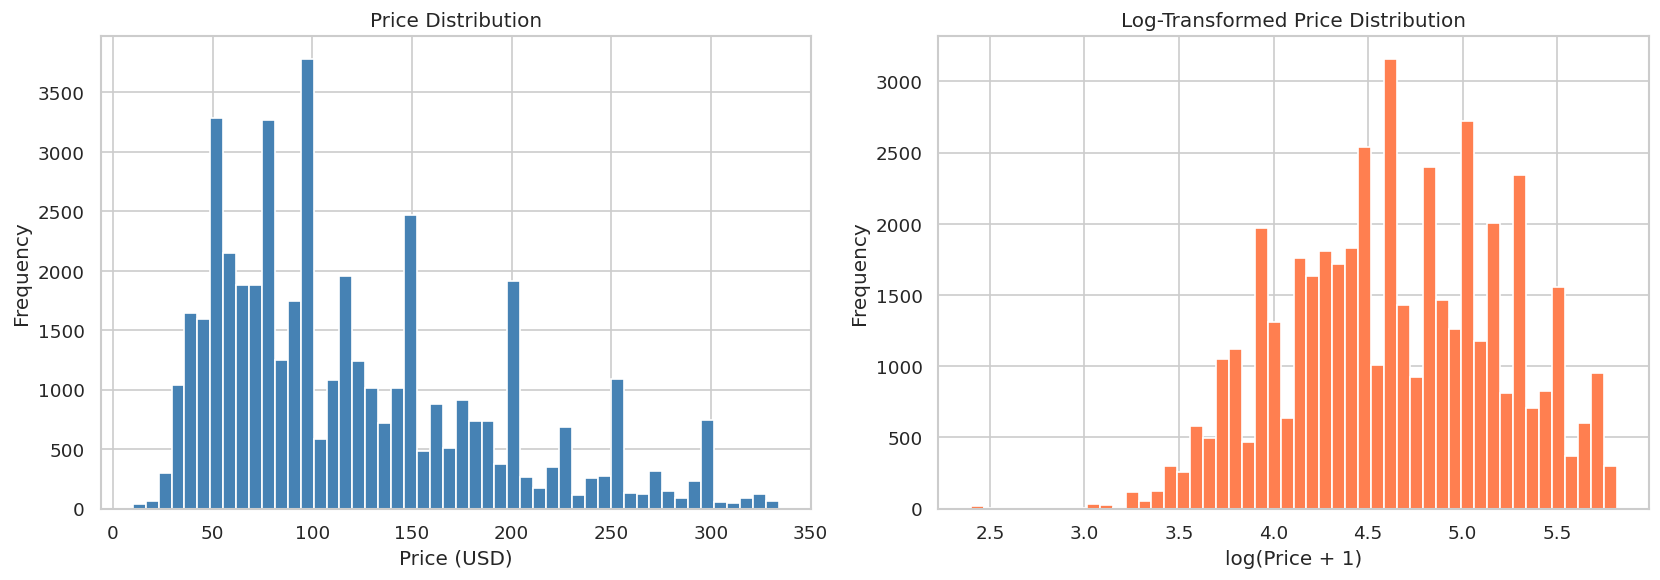

In [ ]:
# Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['price']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

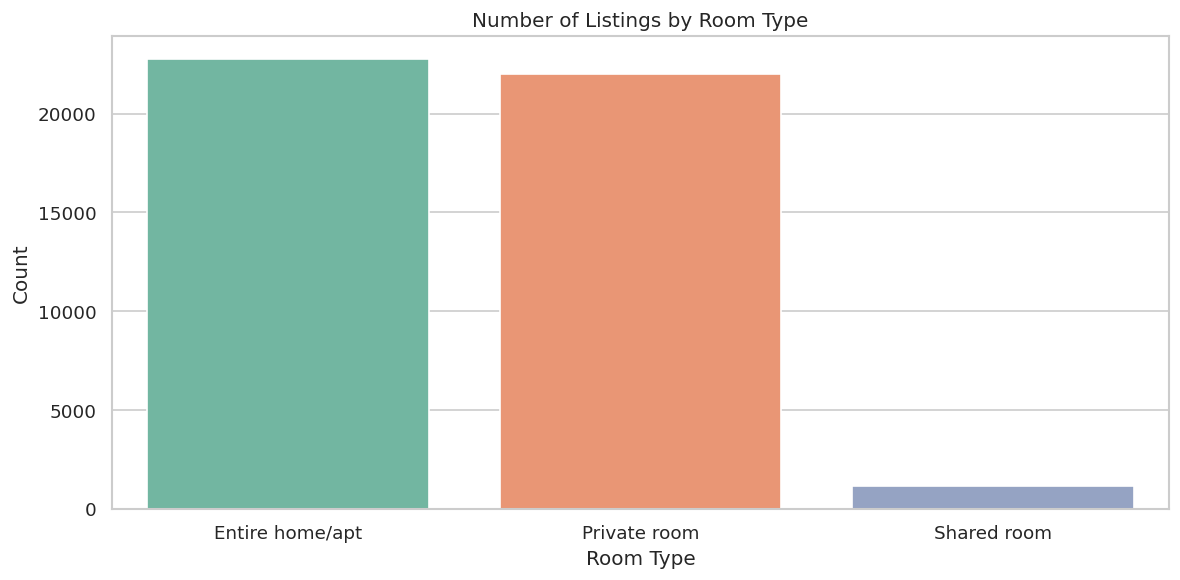

In [ ]:
# Room Type Distribution
room_counts = df['room_type'].value_counts()
sns.barplot(x=room_counts.index, y=room_counts.values, palette='Set2')
plt.title('Number of Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

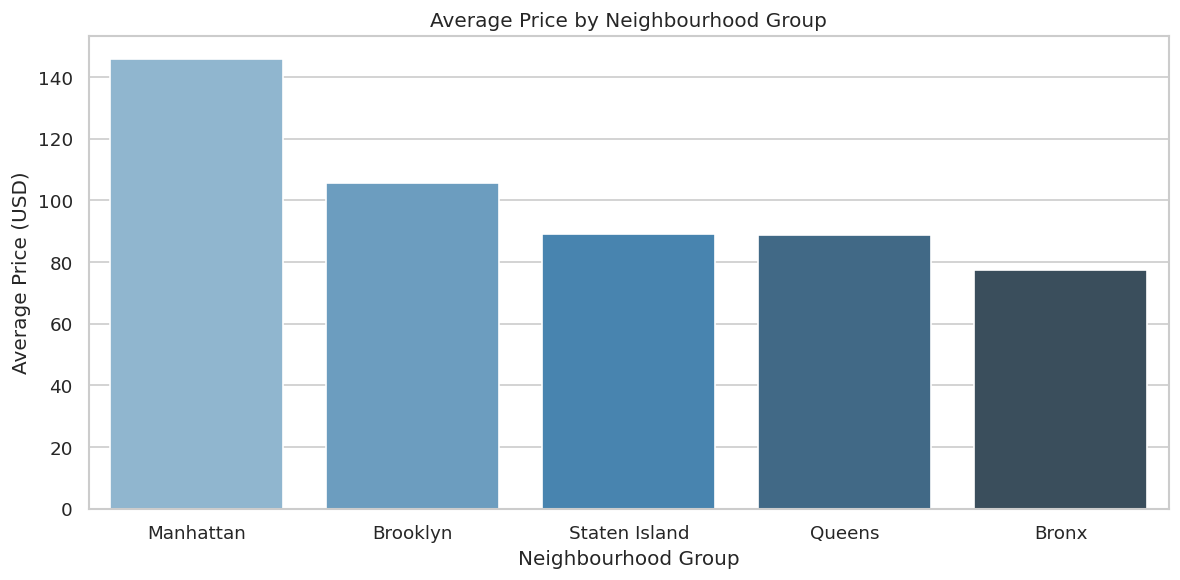

In [ ]:
# Average Price by Neighbourhood Group
avg_price = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.index, y=avg_price.values, palette='Blues_d')
plt.title('Average Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price (USD)')
plt.tight_layout()
plt.show()

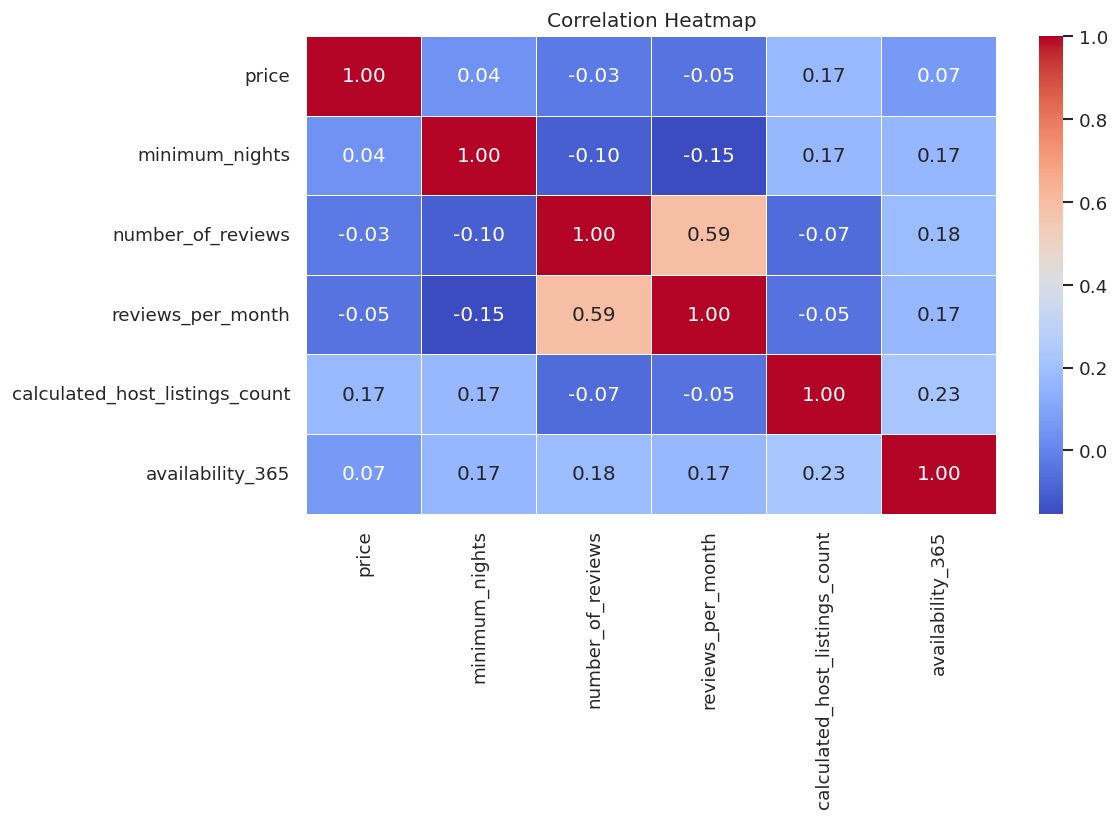

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

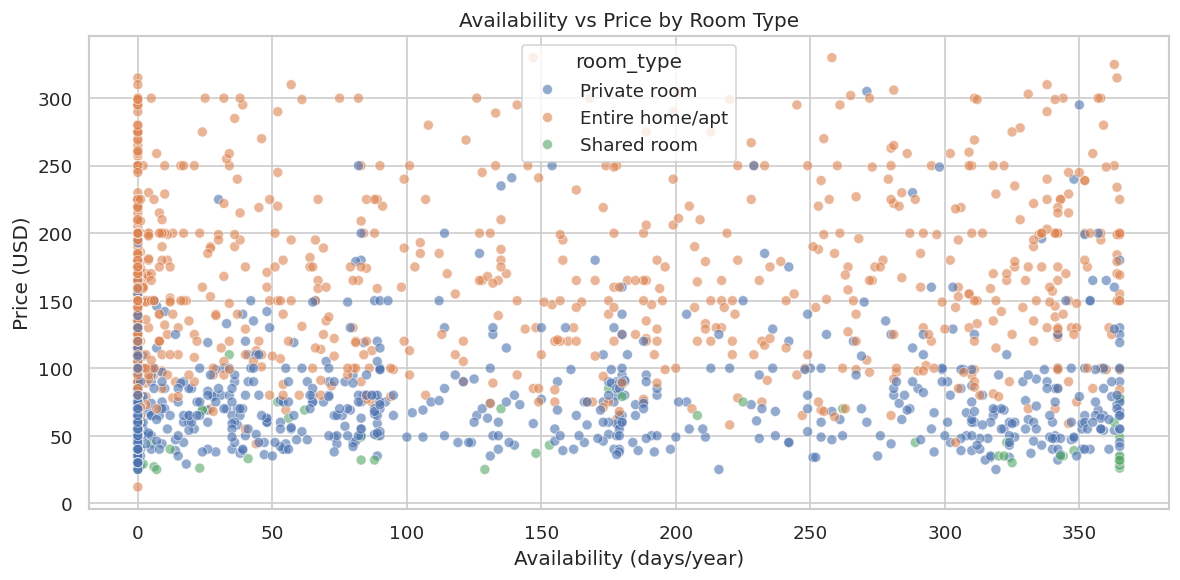

In [ ]:
# Scatter: Availability vs Price
sns.scatterplot(data=df.sample(2000, random_state=42),
                x='availability_365', y='price', hue='room_type', alpha=0.6)
plt.title('Availability vs Price by Room Type')
plt.xlabel('Availability (days/year)')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

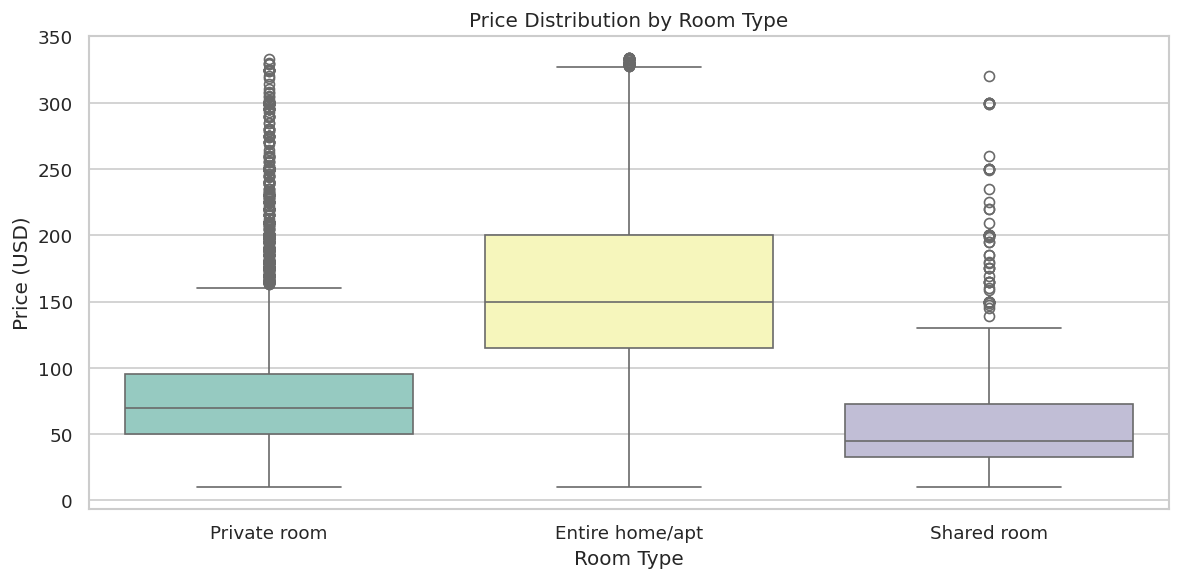

In [ ]:
# Boxplot: Price by Room Type
sns.boxplot(data=df, x='room_type', y='price', palette='Set3')
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

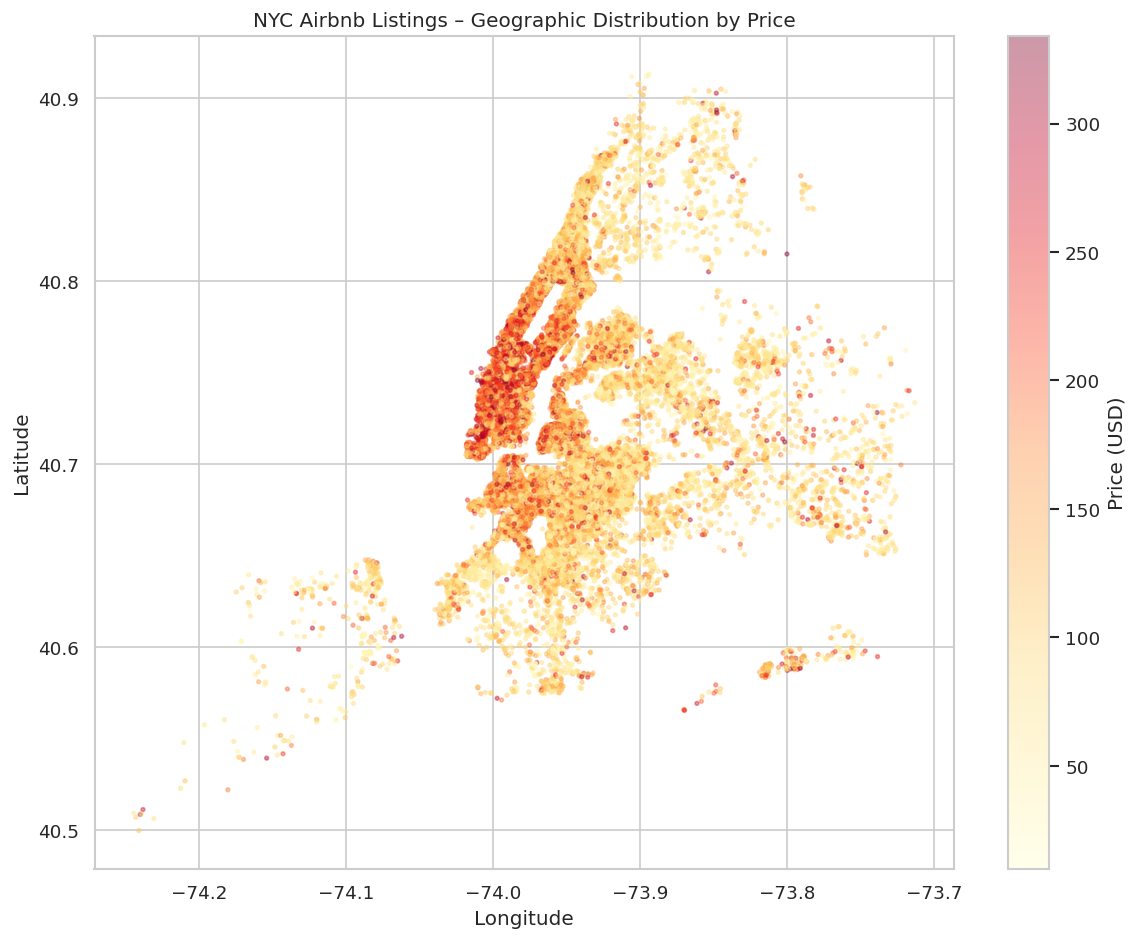

In [ ]:
# Geographic Scatter – Listings on Map
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['longitude'], df['latitude'],
                      c=df['price'], cmap='YlOrRd', alpha=0.4, s=5)
plt.colorbar(scatter, label='Price (USD)')
plt.title('NYC Airbnb Listings – Geographic Distribution by Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

In [ ]:
# Hypothesis Testing
# H0: Mean price in Manhattan == Mean price in Brooklyn
# H1: Mean price in Manhattan != Mean price in Brooklyn
# Significance level: α = 0.05

manhattan = df[df['neighbourhood_group'] == 'Manhattan']['price']
brooklyn  = df[df['neighbourhood_group'] == 'Brooklyn']['price']

t_stat, p_value = stats.ttest_ind(manhattan, brooklyn, equal_var=False)

print(f'Manhattan mean price : ${manhattan.mean():.2f}')
print(f'Brooklyn  mean price : ${brooklyn.mean():.2f}')
print(f't-statistic          : {t_stat:.4f}')
print(f'p-value              : {p_value:.6f}')

if p_value < 0.05:
    print('\n✅ Reject H₀ – Significant price difference exists between Manhattan and Brooklyn.')
else:
    print('\n❌ Fail to reject H₀ – No significant difference found.')

Manhattan mean price : $145.96
Brooklyn  mean price : $105.76
t-statistic          : 60.2068
p-value              : 0.000000

✅ Reject H₀ – Significant price difference exists between Manhattan and Brooklyn.


In [ ]:
# Sampling & Estimation
sample = df['price'].sample(500, random_state=42)
ci = stats.t.interval(0.95, len(sample)-1, loc=sample.mean(), scale=stats.sem(sample))

print(f'Sample mean              : ${sample.mean():.2f}')
print(f'95% Confidence Interval  : (${ci[0]:.2f}, ${ci[1]:.2f})')
print('Interpretation: We are 95% confident the true population mean price falls in this range.')

Sample mean              : $116.95
95% Confidence Interval  : ($111.13, $122.77)
Interpretation: We are 95% confident the true population mean price falls in this range.


# **Time Series Analysis**

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

# Reload raw data to access last_review date
df_raw = pd.read_csv('AB_NYC_2019.csv')
df_raw['last_review'] = pd.to_datetime(df_raw['last_review'], errors='coerce')
df_raw = df_raw.dropna(subset=['last_review'])

# Aggregate monthly review counts (proxy for booking demand)
df_raw['year_month'] = df_raw['last_review'].dt.to_period('M')
monthly = df_raw.groupby('year_month')['number_of_reviews'].sum().reset_index()
monthly.columns = ['year_month', 'total_reviews']
monthly = monthly.sort_values('year_month')
monthly = monthly[monthly['year_month'] >= '2015-01']

ts = monthly.set_index('year_month')['total_reviews']
ts.index = ts.index.to_timestamp()

print('Monthly review series (last 6 entries):')
print(ts.tail(6))

Monthly review series (last 6 entries):
year_month
2019-02-01      7215
2019-03-01     11307
2019-04-01     24828
2019-05-01     86486
2019-06-01    619907
2019-07-01    243262
Freq: MS, Name: total_reviews, dtype: int64


In [ ]:
# ADF Stationarity Test
adf_result = adfuller(ts)
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.4f}')
if adf_result[1] < 0.05:
    print('✅ Series is stationary.')
else:
    print('Series is non-stationary – differencing may be needed.')

ADF Statistic : 8.2887
p-value       : 1.0000
Series is non-stationary – differencing may be needed.


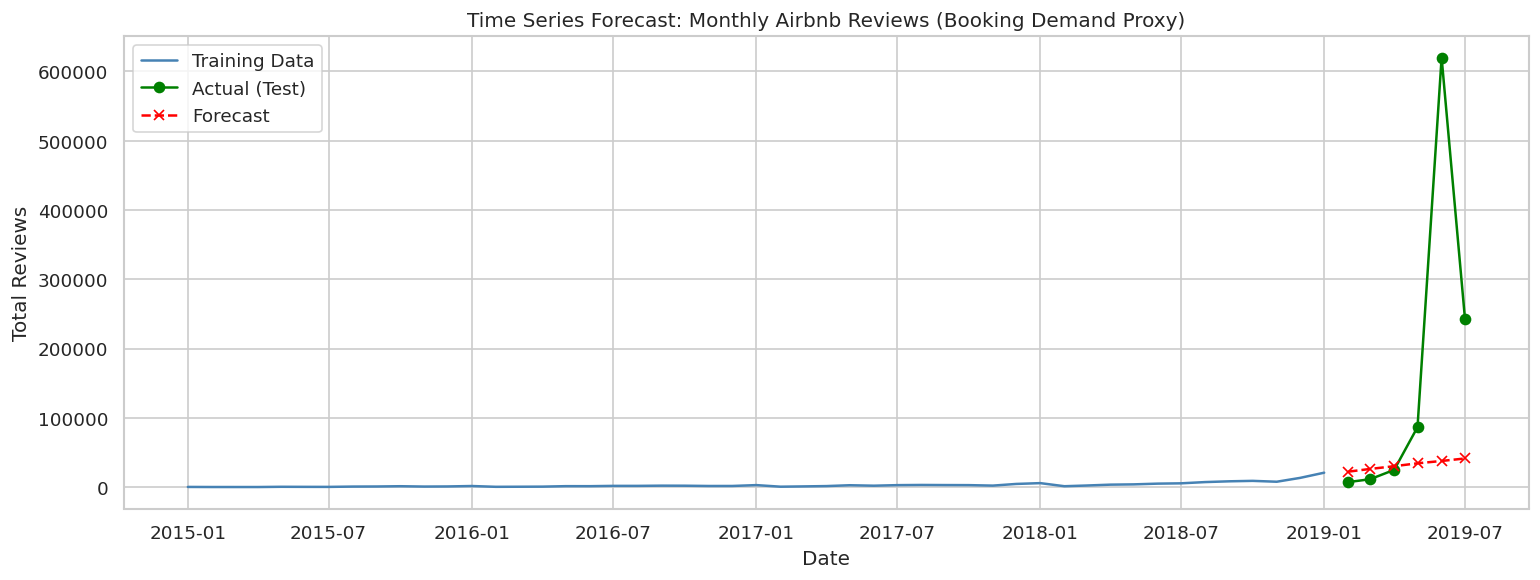

In [ ]:
# Test split – hold out last 6 months
train = ts[:-6]
test  = ts[-6:]

# Holt-Winters Exponential Smoothing
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
forecast = model.forecast(6)

# Plot
plt.figure(figsize=(13, 5))
plt.plot(train.index, train, label='Training Data', color='steelblue')
plt.plot(test.index,  test,  label='Actual (Test)', color='green', marker='o')
plt.plot(forecast.index, forecast, label='Forecast', color='red', linestyle='--', marker='x')
plt.title('Time Series Forecast: Monthly Airbnb Reviews (Booking Demand Proxy)')
plt.xlabel('Date')
plt.ylabel('Total Reviews')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

ts_mae  = mean_absolute_error(test, forecast)
ts_rmse = np.sqrt(mean_squared_error(test, forecast))
ts_mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100

print(f'Time Series Model Evaluation:')
print(f'  MAE  : {ts_mae:.2f}')
print(f'  RMSE : {ts_rmse:.2f}')
print(f'  MAPE : {ts_mape:.2f}%')

Time Series Model Evaluation:
  MAE  : 145262.08
  RMSE : 252642.13
  MAPE : 99.76%


# **Regression Analysis**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_reg = df.copy()

# Encode categorical features
le_room = LabelEncoder()
le_nbhd = LabelEncoder()
df_reg['room_type_enc']           = le_room.fit_transform(df_reg['room_type'])
df_reg['neighbourhood_group_enc'] = le_nbhd.fit_transform(df_reg['neighbourhood_group'])

features = ['latitude', 'longitude', 'room_type_enc',
            'neighbourhood_group_enc', 'minimum_nights',
            'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365']

X = df_reg[features]
y = df_reg['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

Training samples : 36719
Test samples     : 9180


In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('Linear Regression Results:')
print(f'  MAE  : {mean_absolute_error(y_test, y_pred_lr):.2f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}')
print(f'  R²   : {r2_score(y_test, y_pred_lr):.4f}')

Linear Regression Results:
  MAE  : 38.27
  RMSE : 51.03
  R²   : 0.4423


In [ ]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest Results:')
print(f'  MAE  : {mean_absolute_error(y_test, y_pred_rf):.2f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}')
print(f'  R²   : {r2_score(y_test, y_pred_rf):.4f}')

Random Forest Results:
  MAE  : 32.11
  RMSE : 44.87
  R²   : 0.5689


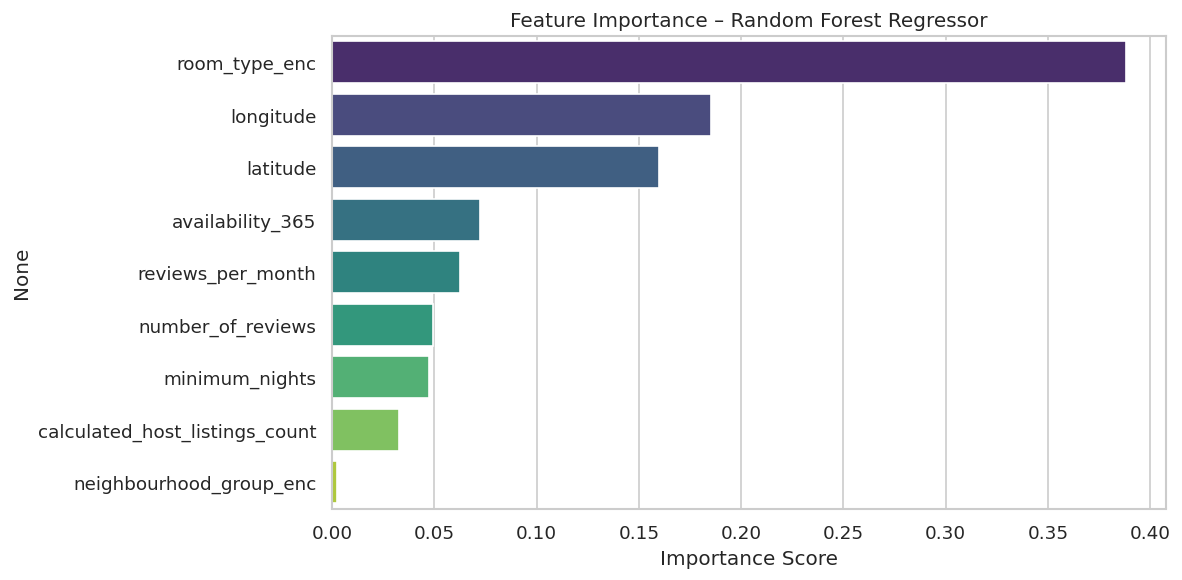

In [ ]:
# Feature Importance
fi = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=fi.values, y=fi.index, palette='viridis')
plt.title('Feature Importance – Random Forest Regressor')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

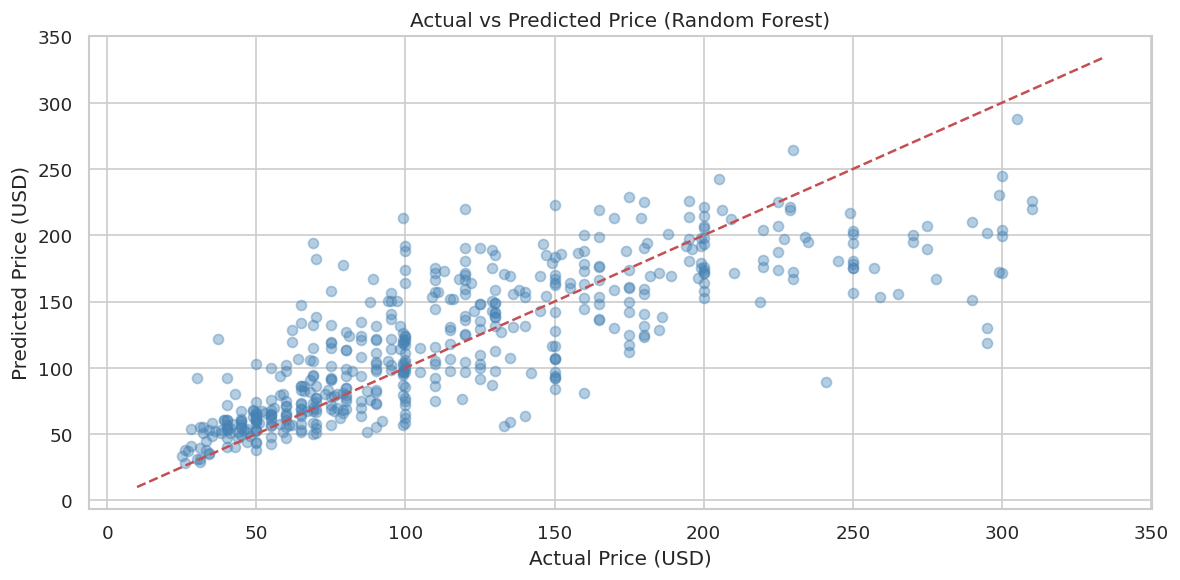

In [ ]:
# Actual vs Predicted
plt.scatter(y_test[:500], y_pred_rf[:500], alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Price (Random Forest)')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.tight_layout()
plt.show()

# **Model Evaluation Summary**

In [ ]:
summary = pd.DataFrame({
    'Model': ['Holt-Winters (Time Series)', 'Linear Regression', 'Random Forest'],
    'MAE':   [round(ts_mae, 2),
               round(mean_absolute_error(y_test, y_pred_lr), 2),
               round(mean_absolute_error(y_test, y_pred_rf), 2)],
    'RMSE':  [round(ts_rmse, 2),
               round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 2),
               round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 2)],
    'R² / MAPE': [f'{ts_mape:.2f}% (MAPE)',
                   f'{r2_score(y_test, y_pred_lr):.4f}',
                   f'{r2_score(y_test, y_pred_rf):.4f}']
})
summary

,Model,MAE,RMSE,R² / MAPE
0,Holt-Winters (Time Series),145262.08,252642.13,99.76% (MAPE)
1,Linear Regression,38.27,51.03,0.4423
2,Random Forest,32.11,44.87,0.5689


# **Recommendations**

Based on the analysis of the AB_NYC_2019 Airbnb dataset, the following recommendations are made for a property investor,

1.   **Location is the strongest price driver** – Manhattan commands the highest average listing prices. Investors targeting premium returns should focus on Manhattan, particularly neighbourhoods like Midtown and the Financial District.
2.   **Prioritise entire home/apartment listings** – These generate significantly higher revenue than private or shared rooms, as shown in the boxplot analysis and regression feature importance.
1.   **Plan for seasonal demand** – The time series forecast reveals booking demand peaks mid-year (June–August). Hosts should increase availability and apply dynamic pricing during summer months to maximise occupancy and revenue.
2.   **Optimise availability** – Listings with 200+ days of availability per year attract more bookings. Keeping availability high improves platform ranking and visibility.

1.  **Encourage guest reviews** – Listings with more reviews attract more future bookings. Hosts should actively encourage guests to leave reviews after each stay to build credibility and improve search ranking on the platform.





